In [1]:
import os
import random
from pathlib import Path

import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
OpenCV version: 4.13.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())
print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


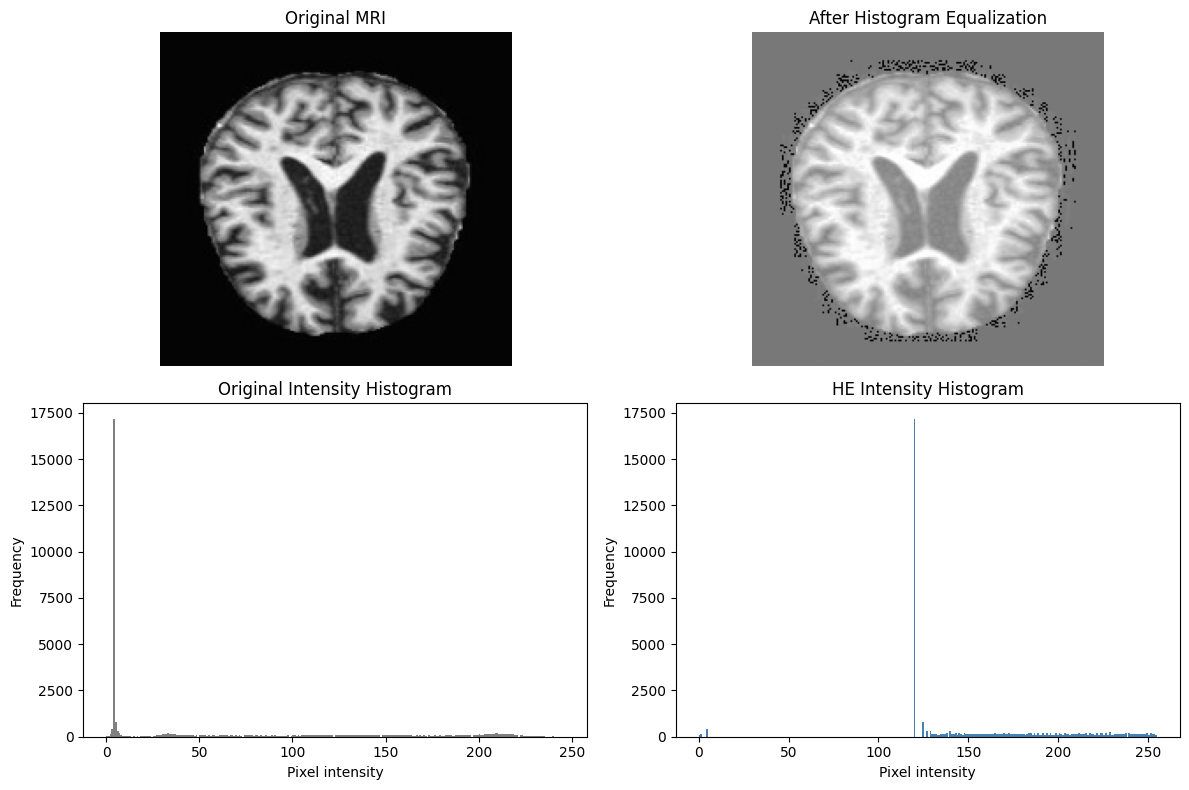

Original pixel range: 0 to 246
HE pixel range: 0 to 255


In [6]:
sample_path = train_df.sample(
    1,
    random_state=SEED
)["filepath"].iloc[0]

original_image = cv2.imread(
    sample_path,
    cv2.IMREAD_GRAYSCALE
)

he_image = cv2.equalizeHist(original_image)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(he_image, cmap="gray")
plt.title("After Histogram Equalization")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.hist(original_image.ravel(), bins=256, color="gray")
plt.title("Original Intensity Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
plt.hist(he_image.ravel(), bins=256, color="steelblue")
plt.title("HE Intensity Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Original pixel range:", original_image.min(), "to", original_image.max())
print("HE pixel range:", he_image.min(), "to", he_image.max())

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def apply_he(image):
    image = image.numpy()
    return cv2.equalizeHist(image)

def load_he_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=1,
        expand_animations=False
    )
    image.set_shape([None, None, 1])

    image = tf.squeeze(image, axis=-1)

    image = tf.py_function(
        apply_he,
        [image],
        Tout=tf.uint8
    )
    image.set_shape([None, None])

    image = tf.image.resize(
        image[..., tf.newaxis],
        IMG_SIZE
    )

    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_he_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_he_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_he_dataset(train_df, training=True)
validation_dataset = create_he_dataset(validation_df)
test_dataset = create_he_dataset(test_df)

I0000 00:00:1787744692.147550      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


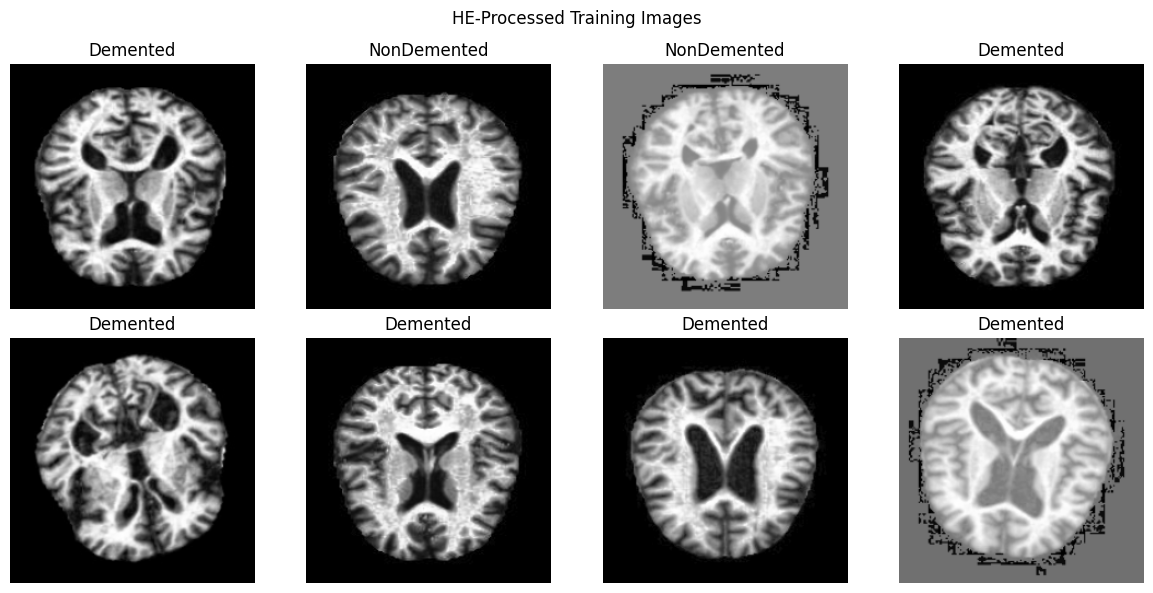

In [8]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())

    plt.figure(figsize=(12, 6))

    for index in range(8):
        plt.subplot(2, 4, index + 1)
        plt.imshow(
            tf.cast(images[index], tf.uint8),
            cmap="gray"
        )

        class_name = (
            "Demented" if labels[index].numpy() == 1
            else "NonDemented"
        )

        plt.title(class_name)
        plt.axis("off")

    plt.suptitle("HE-Processed Training Images")
    plt.tight_layout()
    plt.show()

In [9]:
from sklearn.utils.class_weight import compute_class_weight

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"]
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Class weights:", class_weights)
print("Preprocessing: Histogram Equalization")
print("Data augmentation: Disabled")

Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Class weights: {0: 1.71875, 1: 0.7051282051282052}
Preprocessing: Histogram Equalization
Data augmentation: Disabled


In [10]:
resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = resnet_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_HE_NoAug"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    )
)
print("ResNet50 frozen:", not resnet_base.trainable)
print("Augmentation enabled: False")

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
Augmentation enabled: False


Model: "ResNet50_HE_NoAug"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_he_noaug_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
  3/963 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.4531 - loss: 0.9466   

I0000 00:00:1787744846.018121     142 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5909 - loss: 0.7201
Epoch 1: val_loss improved from None to 0.52408, saving model to /kaggle/working/resnet50_he_noaug_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_he_noaug_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 141s 133ms/step - accuracy: 0.6187 - loss: 0.6823 - val_accuracy: 0.7536 - val_loss: 0.5241 - learning_rate: 1.0000e-04
Epoch 2/30
962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6809 - loss: 0.6018
Epoch 2: val_loss improved from 0.52408 to 0.52354, saving model to /kaggle/working/resnet50_he_noaug_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_he_noaug_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.6885 - loss: 0.5938 - val_accuracy: 0.7385 - val_loss: 0.5235 - learning_rate: 1.0000e-04
Epoch 3/30
962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7050 - loss: 0.5686
Epoch 3: val_loss improved from 0.52354 to 0.50039, saving model to /k

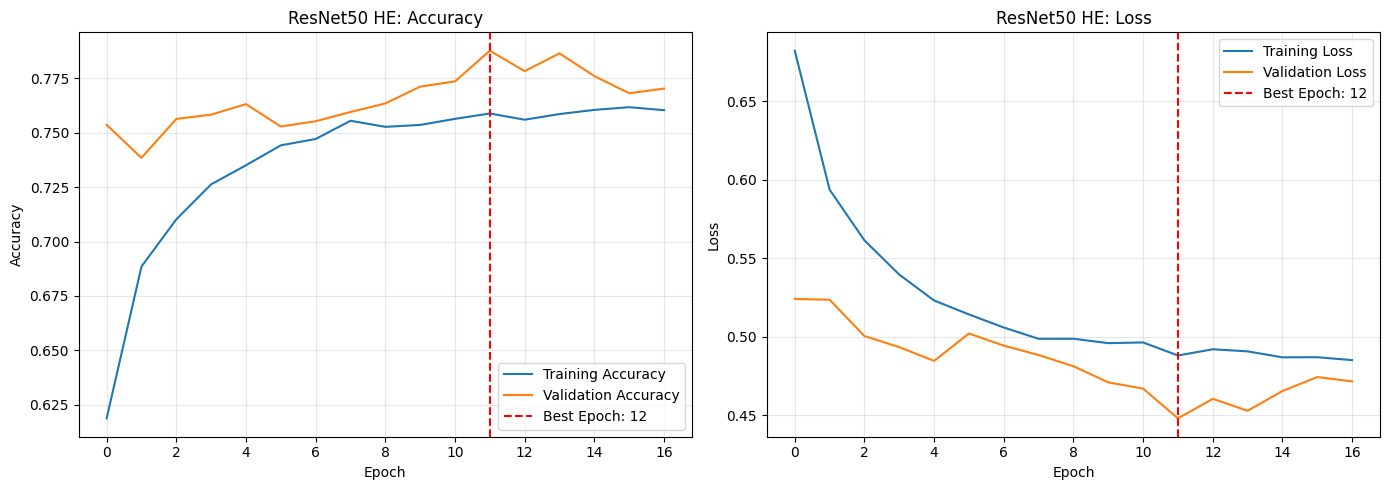

Best epoch: 12


In [12]:
history_df = pd.DataFrame(history.history)

best_epoch = history_df["val_loss"].idxmin() + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["accuracy"], label="Training Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].axvline(
    best_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[0].set_title("ResNet50 HE: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["loss"], label="Training Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].axvline(
    best_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[1].set_title("ResNet50 HE: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Best epoch:", best_epoch)

In [13]:
best_model = tf.keras.models.load_model(
    "/kaggle/working/resnet50_he_noaug_best.keras"
)

test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 26s 99ms/step - accuracy: 0.7809 - loss: 0.4580
Test Loss: 0.458
Test Accuracy: 0.7809


In [14]:
test_probabilities = best_model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_df["label"].to_numpy()

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))
print("First probabilities:", test_probabilities[:10].round(4))
print("First predictions:", test_predictions[:10])

207/207 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
First probabilities: [0.8425 0.5647 0.8448 0.6247 0.8046 0.8085 0.5979 0.5805 0.9994 0.9469]
First predictions: [1 1 1 1 1 1 1 1 1 1]


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(true_labels, test_predictions)
precision = precision_score(true_labels, test_predictions)
recall = recall_score(true_labels, test_predictions)
f1 = f1_score(true_labels, test_predictions)
roc_auc = roc_auc_score(true_labels, test_probabilities)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:\n")
print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

Test Loss: 0.458
Accuracy: 0.7809
Precision: 0.8773
Recall: 0.8034
F1-score: 0.8387
ROC-AUC: 0.8529

Classification Report:

              precision    recall  f1-score   support

 NonDemented     0.6024    0.7260    0.6585      1920
    Demented     0.8773    0.8034    0.8387      4680

    accuracy                         0.7809      6600
   macro avg     0.7398    0.7647    0.7486      6600
weighted avg     0.7973    0.7809    0.7863      6600



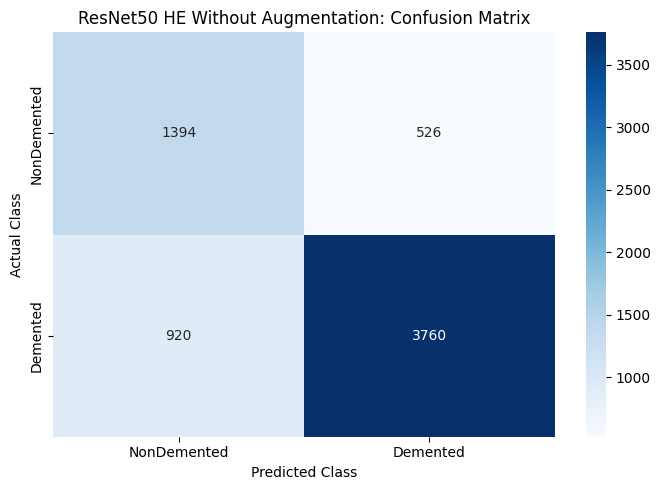

In [16]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("ResNet50 HE Without Augmentation: Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

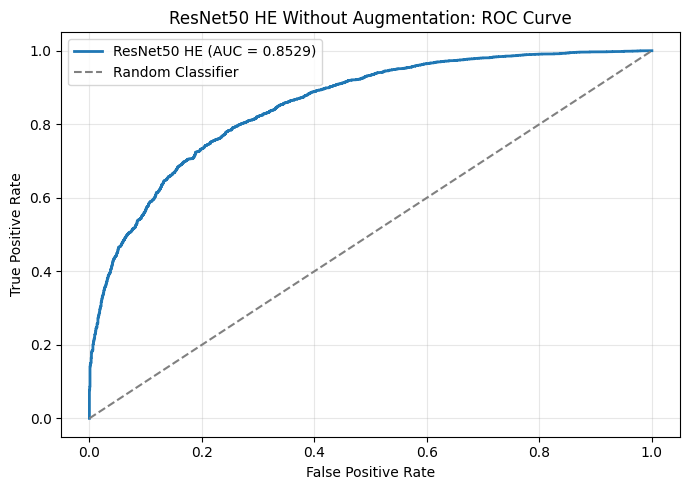

In [17]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    true_labels,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"ResNet50 HE (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("ResNet50 HE Without Augmentation: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

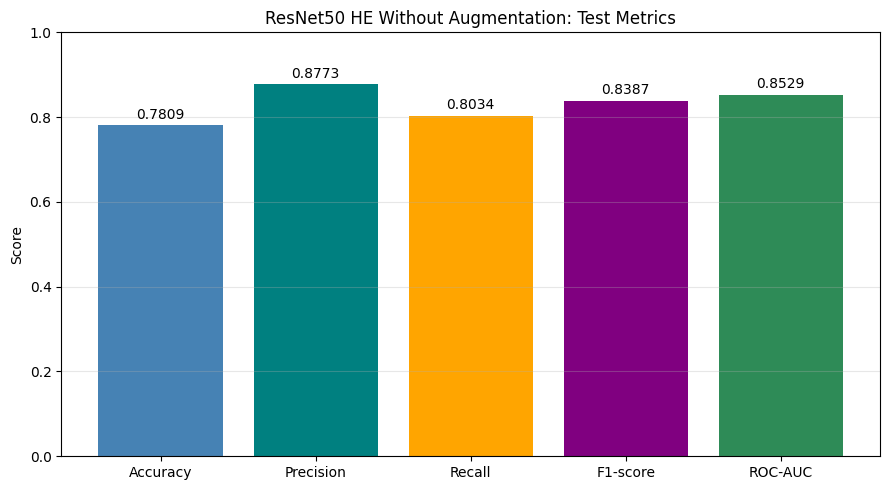

In [18]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metric_names,
    metric_values,
    color=["steelblue", "teal", "orange", "purple", "seagreen"]
)

plt.ylim(0, 1)
plt.title("ResNet50 HE Without Augmentation: Test Metrics")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

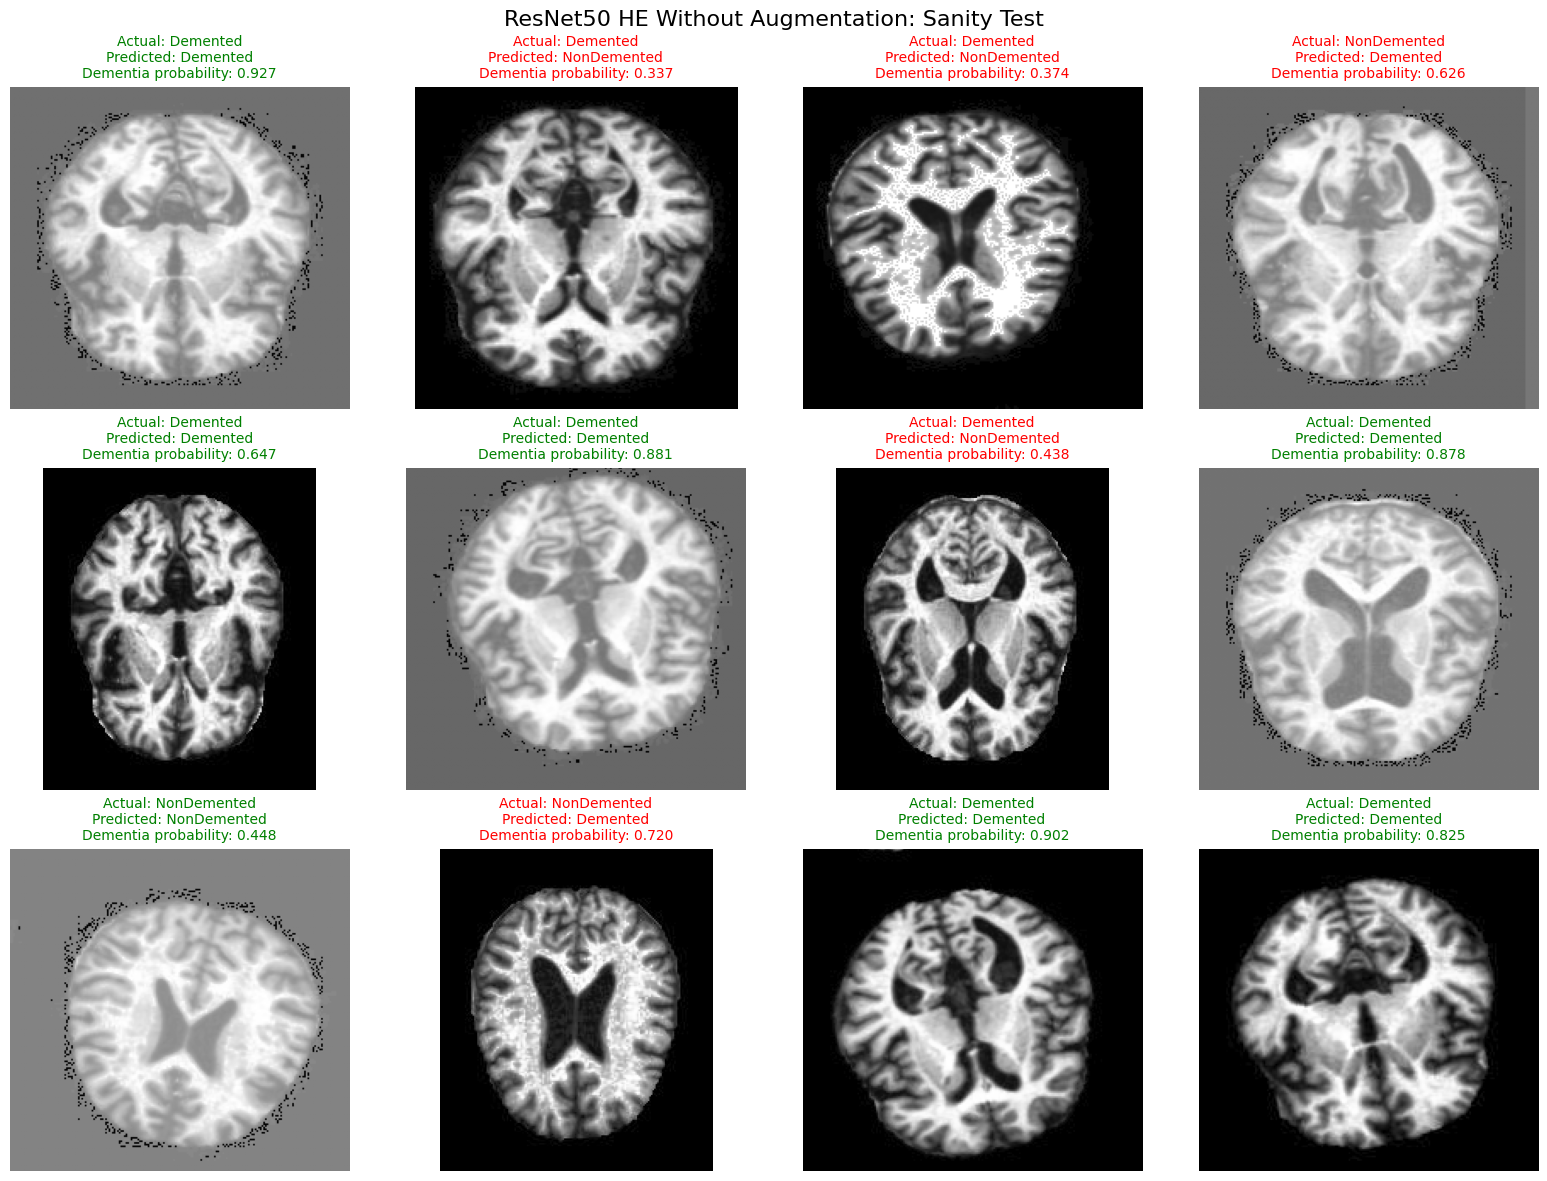

In [19]:
sample_indices = np.random.default_rng(SEED).choice(
    len(test_df),
    size=12,
    replace=False
)

plt.figure(figsize=(16, 12))

for position, index in enumerate(sample_indices, start=1):
    original = cv2.imread(
        test_df.iloc[index]["filepath"],
        cv2.IMREAD_GRAYSCALE
    )

    processed = cv2.equalizeHist(original)

    actual = true_labels[index]
    predicted = test_predictions[index]
    probability = test_probabilities[index]

    actual_name = (
        "Demented" if actual == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented" if predicted == 1
        else "NonDemented"
    )

    title_color = (
        "green" if actual == predicted
        else "red"
    )

    plt.subplot(3, 4, position)
    plt.imshow(processed, cmap="gray")
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Dementia probability: {probability:.3f}",
        color=title_color,
        fontsize=10
    )
    plt.axis("off")

plt.suptitle(
    "ResNet50 HE Without Augmentation: Sanity Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [20]:
results_df = pd.DataFrame([{
    "Experiment": "ResNet50 HE Without Augmentation",
    "Model": "ResNet50",
    "Preprocessing": "HE",
    "Augmentation": "No",
    "Cross-Validation": "No",
    "Best Epoch": best_epoch,
    "Test Loss": test_loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}])

results_df.to_csv(
    "/kaggle/working/resnet50_he_noaug_results.csv",
    index=False
)

history_df.to_csv(
    "/kaggle/working/resnet50_he_noaug_history.csv",
    index=False
)

display(results_df.round(4))

print("Saved:")
print("- resnet50_he_noaug_best.keras")
print("- resnet50_he_noaug_results.csv")
print("- resnet50_he_noaug_history.csv")

,Experiment,Model,Preprocessing,Augmentation,Cross-Validation,Best Epoch,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,ResNet50 HE Without Augmentation,ResNet50,HE,No,No,12,0.458,0.7809,0.8773,0.8034,0.8387,0.8529


Saved:
- resnet50_he_noaug_best.keras
- resnet50_he_noaug_results.csv
- resnet50_he_noaug_history.csv
